# Task 7: Machine Translation (English ↔ Dutch)

## Objective
Build one bidirectional model for round-translation of speech transcripts.

## Dataset
- Corpus Name: OpenSubtitles
- Package: Moses
- Website: http://opus.nlpl.eu/legacy/OpenSubtitles-v2024.php
- Release: v2024
- Release date: Fri Feb 14 10:40:45 EET 2025

In [3]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import re
import random
import nltk
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu

In [6]:
np.random.seed(42)
tf.random.set_seed(42)

## Step 1: Dataset Selection & Loading

- Select and download an EN-NL dataset
- Load the data
- Basic exploration and quality checks
- Sample to manageable size (100k-200k pairs)

In [7]:
# Load the OpenSubtitles data
with open('OpenSubtitles.en-nl.en', 'r', encoding='utf-8') as f:
    en_sentences = [line.strip() for line in f.readlines()]

with open('OpenSubtitles.en-nl.nl', 'r', encoding='utf-8') as f:
    nl_sentences = [line.strip() for line in f.readlines()]

In [8]:
# Sample to manageable size
SAMPLE_SIZE = 100000 

# Sample randomly to get diverse data
indices = random.sample(range(len(en_sentences)), SAMPLE_SIZE)
en_sentences = [en_sentences[i] for i in sorted(indices)]
nl_sentences = [nl_sentences[i] for i in sorted(indices)]

print(f"Sampled {len(en_sentences)} sentence pairs")

Sampled 100000 sentence pairs


In [9]:
# Check alignment
assert len(en_sentences) == len(nl_sentences), 'Misaligned files!'

# Check for empty sentences
en_empty = sum(1 for s in en_sentences if not s.strip())
nl_empty = sum(1 for s in nl_sentences if not s.strip())
print(f'Empty EN sentences: {en_empty}')
print(f'Empty NL sentences: {nl_empty}')

Empty EN sentences: 0
Empty NL sentences: 0


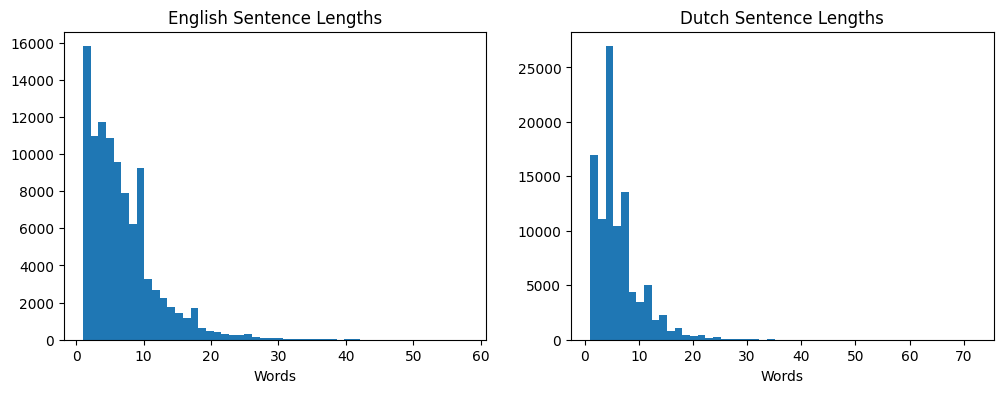

In [10]:
# Length distribution
en_lengths = [len(s.split()) for s in en_sentences]
nl_lengths = [len(s.split()) for s in nl_sentences]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(en_lengths, bins=50)
ax1.set_title('English Sentence Lengths')
ax1.set_xlabel('Words')
ax2.hist(nl_lengths, bins=50)
ax2.set_title('Dutch Sentence Lengths')
ax2.set_xlabel('Words')
plt.show()

In [11]:
# Basic preprocessing
def preprocess_sentence(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r'([?.!,¿])', r' \1 ', sentence)
    sentence = re.sub(r'[" "]+', ' ', sentence)
    sentence = sentence.strip()
    return '<start> ' + sentence + ' <end>'

en_processed = [preprocess_sentence(s) for s in en_sentences]
nl_processed = [preprocess_sentence(s) for s in nl_sentences]

In [12]:
# Create bidirectional samples with direction tokens
en_to_nl = ['<2nl> ' + en for en in en_processed]
nl_to_en = ['<2en> ' + nl for nl in nl_processed]

# Combine into bidirectional dataset
all_sources = en_to_nl + nl_to_en
all_targets = nl_processed + en_processed

print(f'Total training samples: {len(all_sources)}')

print("\nExample EN→NL sample:")
print(f"Source: {all_sources[0]}")
print(f"Target: {all_targets[0]}")

print("\nExample NL→EN sample:")
print(f"Source: {all_sources[len(en_processed)]}")
print(f"Target: {all_targets[len(en_processed)]}")

Total training samples: 200000

Example EN→NL sample:
Source: <2nl> <start> on what ? <end>
Target: <start> waarvoor ? <end>

Example NL→EN sample:
Source: <2en> <start> waarvoor ? <end>
Target: <start> on what ? <end>


## Step 2: Tokenization & Vocabulary

- Use Keras `TextVectorization`
- Create tokenizers for both EN and NL
- Build vocabularies
- Add special tokens: `<2nl>`, `<2en>`
- Vectorize the data

In [13]:
# Hyperparameters
VOCAB_SIZE = 5000
MAX_SEQ_LENGTH = 40

# Combined text corpus for vocabulary
combined_corpus = all_sources + all_targets

print(f'Building vocabulary from {len(combined_corpus)} sentences')

Building vocabulary from 400000 sentences


In [14]:
# Create single TextVectorization layer for both languages
vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_SEQ_LENGTH,
    standardize=None
)

# Adapt to the combined corpus
vectorizer.adapt(combined_corpus)

# Get vocabulary
vocabulary = vectorizer.get_vocabulary()
print(f'Vocabulary size: {len(vocabulary)} tokens')
print(f'First 20 tokens: {vocabulary[:20]}')

# Check if the special tokens are there
special_tokens = ['<2nl>', '<2en>', '<start>', '<end>']
for token in special_tokens:
    if token in vocabulary:
        print(f'"{token}" found at index {vocabulary.index(token)}')
    else:
        print(f'"{token}" NOT FOUND')

2025-10-06 12:29:48.548925: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1759753788.552093   47496 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 39595 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:61:00.0, compute capability: 8.9


Vocabulary size: 5000 tokens
First 20 tokens: ['', '[UNK]', np.str_('<start>'), np.str_('<end>'), np.str_('.'), np.str_(','), np.str_('<2nl>'), np.str_('<2en>'), np.str_('?'), np.str_('you'), np.str_('ik'), np.str_('the'), np.str_('-'), np.str_('je'), np.str_('is'), np.str_('i'), np.str_('to'), np.str_('het'), np.str_('de'), np.str_('a')]
"<2nl>" found at index 6
"<2en>" found at index 7
"<start>" found at index 2
"<end>" found at index 3


In [15]:
# Split the data
train_src, val_src, train_tgt, val_tgt = train_test_split(
    all_sources, all_targets, test_size=0.2, random_state=42
)

print(f'Training samples: {len(train_src)}')
print(f'Validation sampels: {len(val_src)}')

Training samples: 160000
Validation sampels: 40000


In [16]:
# Vectorize all data
train_src_vec = vectorizer(train_src)
train_tgt_vec = vectorizer(train_tgt)
val_src_vec = vectorizer(val_src)
val_tgt_vec = vectorizer(val_tgt)

print('Vectorized shapes:')
print(f'Train source: {train_src_vec.shape}')
print(f'Train target: {train_tgt_vec.shape}')

Vectorized shapes:
Train source: (160000, 40)
Train target: (160000, 40)


## Step 3: Data Preparation

- Train/validation/test split
- Create TensorFlow datasets with batching

In [17]:
BATCH_SIZE = 32

# Create datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_src_vec, train_tgt_vec))
train_dataset = train_dataset.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((val_src_vec, val_tgt_vec))
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f'Training batches: {len(train_dataset)}')
print(f'Validation batches: {len(val_dataset)}')

Training batches: 5000
Validation batches: 1250


## Step 4: Model Architecture

- Positional Encoding (sinusoidal)
- Multi-Head Attention (scaled dot-product)
- Encoder Layers (self-attention + feed-forward)
- Decoder Layers (masked self-attention + cross-attention + feed-forward)
- Complete Transformer (encoder + decoder + output projection)

In [19]:
def get_positional_encoding(seq_len, d_model):
    """
    Creates sinusoidal positional encodings.
    
    Each position gets a unique vector based on sine/cosine functions
    at different frequencies.
    """
    positions = np.arange(seq_len)[:, np.newaxis]
    dims = np.arange(d_model)[np.newaxis, :]
    angles = positions / np.power(10000, (2 * (dims // 2)) / np.float32(d_model))
    
    # Apply sine to even indices, cosine to odd indices
    pos_encoding = np.zeros((seq_len, d_model))
    pos_encoding[:, 0::2] = np.sin(angles[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(angles[:, 1::2])
    
    return tf.cast(pos_encoding, dtype=tf.float32)

In [20]:
def scaled_dot_product_attention(q, k, v, mask=None):
    """
    Compute scaled dot-product attention.
    Formula: Attention(Q,K,V) = softmax(QK^T/√d_k)V
    
    Args:
        q: Query tensor of shape (..., seq_len_q, d_k)
        k: Key tensor of shape (..., seq_len_k, d_k)
        v: Value tensor of shape (..., seq_len_v, d_v)
        mask: Optional mask tensor
    
    Returns:
        output: Attention output
        attention_weights: Attention weights
    """
    matmul_qk = tf.matmul(q, k, transpose_b=True)
    dk = tf.cast(tf.shape(k)[-1], tf.float32)
    scaled_attention_logits = matmul_qk / tf.sqrt(dk) 
    if mask is not None:
        scaled_attention_logits += (mask * -1e9)
    attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
    output = tf.matmul(attention_weights, v)
    
    return output, attention_weights

In [21]:
class MultiHeadAttention(layers.Layer):
    """
    Multi-head attention: Run attention in parallel with different learned projections.
    """
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.depth = d_model // num_heads
        
        # Create four Dense layers for Q, K, V projections and final output
        self.wq = layers.Dense(d_model)
        self.wk = layers.Dense(d_model)
        self.wv = layers.Dense(d_model)
        self.dense = layers.Dense(d_model)
    
    def split_heads(self, x, batch_size):
        """
        Split the last dimension into (num_heads, depth).
        Transpose to shape (batch_size, num_heads, seq_len, depth)
        """
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        
        # Transpose to (batch_size, num_heads, seq_len, depth)
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, q, k, v, mask=None):
        batch_size = tf.shape(q)[0]
        
        # Project Q, K, V through their respective dense layers
        q = self.wq(q)
        k = self.wk(k)
        v = self.wv(v)
        
        # Split into multiple heads
        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)
        
        # Apply scaled dot-product attention
        scaled_attention, attention_weights = scaled_dot_product_attention(q, k, v, mask)
        
        # Transpose back to (batch_size, seq_len, num_heads, depth)
        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])
        
        # Concatenate heads by reshaping to (batch_size, seq_len, d_model)
        concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.d_model))
        
        # Apply final dense layer
        output = self.dense(concat_attention)
        
        return output, attention_weights

In [22]:
class EncoderLayer(layers.Layer):
    """
    Single encoder layer: Self-attention + Feed-forward + Normalization
    """
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = tf.keras.Sequential([
            layers.Dense(dff, activation='relu'),
            layers.Dense(d_model)
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)
    
    def call(self, x, training=False, mask=None):
        # Apply self-attention
        attn_output, _ = self.mha(x, x, x, mask)
        
        # Apply dropout to attention output
        attn_output = self.dropout1(attn_output, training=training)
        
        # Add residual connection and layer normalization
        out1 = self.layernorm1(x + attn_output)
        
        # Apply feed-forward network
        ffn_output = self.ffn(out1)
        
        # Apply dropout to ffn output
        ffn_output = self.dropout2(ffn_output, training=training)
        
        # Add residual connection and layer normalization
        out2 = self.layernorm2(out1 + ffn_output)
        
        return out2

In [23]:
class Encoder(layers.Layer):
    """
    Complete encoder: Embedding + Positional Encoding + Stack of Encoder Layers
    """
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, maximum_position_encoding, dropout_rate=0.1):
        super().__init__()
        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = layers.Embedding(input_vocab_size, d_model)
        self.pos_encoding = get_positional_encoding(maximum_position_encoding, d_model)
        self.enc_layers = [EncoderLayer(d_model, num_heads, dff, dropout_rate) for _ in range(num_layers)]
        self.dropout = layers.Dropout(dropout_rate)
    
    def call(self, x, training=False, mask=None):
        seq_len = tf.shape(x)[1]
        
        # Embed and add positional encoding
        x = self.embedding(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_encoding[:seq_len, :]
        x = self.dropout(x, training=training)
        
        # Pass through encoder layers
        for enc_layer in self.enc_layers:
            x = enc_layer(x, training=training, mask=mask)
        
        return x

In [24]:
def create_look_ahead_mask(size):
    """
    Creates causal mask: position i can only attend to positions <= i
    
    Returns a matrix where position (i,j) is 0 if i >= j (can attend) 
    and 1 if i < j (cannot attend to future positions)
    """
    mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
    return mask

In [25]:
class DecoderLayer(layers.Layer):
    """
    Single decoder layer: Masked Self-attention + Cross-attention + Feed-forward
    """
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        
        self.mha1 = MultiHeadAttention(d_model, num_heads)
        self.mha2 = MultiHeadAttention(d_model, num_heads)
        self.ffn = tf.keras.Sequential([
            layers.Dense(dff, activation='relu'),
            layers.Dense(d_model)
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm3 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)
        self.dropout3 = layers.Dropout(dropout_rate)
    
    def call(self, x, encoder_output, training=False, look_ahead_mask=None, padding_mask=None):
        # Apply masked self-attention
        attn1, attn_weights_block1 = self.mha1(x, x, x, look_ahead_mask)
        attn1 = self.dropout1(attn1, training=training)
        
        # Add & norm
        out1 = self.layernorm1(x + attn1)
        
        # Apply cross-attention
        attn2, attn_weights_block2 = self.mha2(out1, encoder_output, encoder_output, padding_mask)
        attn2 = self.dropout2(attn2, training=training)
        
        # Add & norm
        out2 = self.layernorm2(out1 + attn2)
        
        # Apply feed-forward network
        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output, training=training)
        
        # Add & norm
        out3 = self.layernorm3(out2 + ffn_output)
        
        return out3, attn_weights_block1, attn_weights_block2

In [26]:
class Decoder(layers.Layer):
    """
    Complete decoder: Embedding + Positional Encoding + Stack of Decoder Layers
    """
    def __init__(self, num_layers, d_model, num_heads, dff, target_vocab_size, maximum_position_encoding, dropout_rate=0.1):
        super().__init__()
        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = layers.Embedding(target_vocab_size, d_model)
        self.pos_encoding = get_positional_encoding(maximum_position_encoding, d_model)
        self.dec_layers = [DecoderLayer(d_model, num_heads, dff, dropout_rate) for _ in range(num_layers)]
        self.dropout = layers.Dropout(dropout_rate)
    
    def call(self, x, encoder_output, training, look_ahead_mask=None, padding_mask=None):
        seq_len = tf.shape(x)[1]
        attention_weights = {}
        
        # Embed the input tokens
        x = self.embedding(x)
        
        # Scale embeddings
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        
        # Add positional encoding
        x += self.pos_encoding[:seq_len, :]
        
        # Apply dropout
        x = self.dropout(x, training=training)
        
        # Pass through all decoder layers
        for i, dec_layer in enumerate(self.dec_layers):
            x, block1, block2 = dec_layer(x, encoder_output, training=training, look_ahead_mask=look_ahead_mask, padding_mask=padding_mask)
            attention_weights[f'decoder_layer{i+1}_block1'] = block1
            attention_weights[f'decoder_layer{i+1}_block2'] = block2
        
        return x, attention_weights

In [27]:
class Transformer(keras.Model):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, target_vocab_size, 
                 max_pe_input, max_pe_target, dropout_rate=0.1):
        super().__init__()
        self.encoder = Encoder(num_layers, d_model, num_heads, dff, input_vocab_size, max_pe_input, dropout_rate)
        self.decoder = Decoder(num_layers, d_model, num_heads, dff, target_vocab_size, max_pe_target, dropout_rate)
        self.final_layer = layers.Dense(target_vocab_size)
    
    def call(self, inputs, training):
        inp, tar = inputs
        
        # Create look-ahead mask for decoder
        look_ahead_mask = create_look_ahead_mask(tf.shape(tar)[1])
        
        # Encode source
        enc_output = self.encoder(inp, training=training, mask=None)
        
        # Decode to target
        dec_output, attention_weights = self.decoder(
            tar,
            enc_output, 
            training=training, 
            look_ahead_mask=look_ahead_mask, 
            padding_mask=None)
        
        # Project to vocabulary
        final_output = self.final_layer(dec_output)
        
        return final_output, attention_weights

In [28]:
# Model hyperparameters
NUM_LAYERS = 4
D_MODEL = 128
NUM_HEADS = 8
DFF = 512

# Create transformer
transformer = Transformer(
    num_layers=NUM_LAYERS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dff=DFF,
    input_vocab_size=len(vocabulary),
    target_vocab_size=len(vocabulary),
    max_pe_input=MAX_SEQ_LENGTH,
    max_pe_target=MAX_SEQ_LENGTH
)

print(f'Model created: {NUM_LAYERS} layers, {D_MODEL} dims, {NUM_HEADS} heads')

Model created: 4 layers, 128 dims, 8 heads


## Step 5: Training

- Custom learning rate schedule (warmup + decay)
- Loss function with padding mask
- Training loop with teacher forcing
- Validation monitoring
- Checkpoint saving

In [29]:
class CustomSchedule(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=4000):
        super().__init__()
        self.d_model = tf.cast(d_model, tf.float32)
        self.warmup_steps = warmup_steps
    
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

learning_rate = CustomSchedule(D_MODEL)
optimizer = keras.optimizers.Adam(learning_rate, beta_1=0.9, beta_2=0.98, epsilon=1e-9)

loss_object = keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

def loss_function(real, pred):
    """Calculate loss, ignoring padding tokens (index 0)"""
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)
    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask
    return tf.reduce_sum(loss_) / tf.reduce_sum(mask)

train_loss = keras.metrics.Mean(name='train_loss')
train_accuracy = keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')

In [30]:
@tf.function
def train_step(inp, tar):
    """One training step with teacher forcing"""
    tar_inp = tar[:, :-1]  # Decoder input: all but last token
    tar_real = tar[:, 1:]  # Expected output: all but first token
    
    with tf.GradientTape() as tape:
        predictions, _ = transformer((inp, tar_inp), training=True)
        loss = loss_function(tar_real, predictions)
    
    # Compute and apply gradients
    gradients = tape.gradient(loss, transformer.trainable_variables)
    optimizer.apply_gradients(zip(gradients, transformer.trainable_variables))
    
    train_loss(loss)
    train_accuracy(tar_real, predictions)
    return loss

In [33]:
EPOCHS = 10

print('Starting training...')

for epoch in range(EPOCHS):
    train_loss.reset_state()
    train_accuracy.reset_state()

    for batch, (inp, tar) in enumerate(train_dataset):
        train_step(inp, tar)

        if batch % 50 == 0:
            print(f'Epoch {epoch + 1}, Batch {batch}, Loss {train_loss.result():.4f}, Acc {train_accuracy.result():.4f}')

    print(f'\nEpoch {epoch + 1} Complete - Loss {train_loss.result():.4f}, Acc {train_accuracy.result():.4f}\n')

    # Save checkpoint every epoch
    transformer.save_weights(f'transformer_epoch_{epoch+1}.weights.h5')

Starting training...
Epoch 1, Batch 0, Loss 3.4492, Acc 0.0857
Epoch 1, Batch 50, Loss 3.3884, Acc 0.0937
Epoch 1, Batch 100, Loss 3.3719, Acc 0.0941
Epoch 1, Batch 150, Loss 3.3637, Acc 0.0948
Epoch 1, Batch 200, Loss 3.3627, Acc 0.0947
Epoch 1, Batch 250, Loss 3.3668, Acc 0.0943
Epoch 1, Batch 300, Loss 3.3632, Acc 0.0941
Epoch 1, Batch 350, Loss 3.3631, Acc 0.0939
Epoch 1, Batch 400, Loss 3.3650, Acc 0.0940
Epoch 1, Batch 450, Loss 3.3575, Acc 0.0941
Epoch 1, Batch 500, Loss 3.3567, Acc 0.0942
Epoch 1, Batch 550, Loss 3.3539, Acc 0.0943
Epoch 1, Batch 600, Loss 3.3559, Acc 0.0945
Epoch 1, Batch 650, Loss 3.3536, Acc 0.0946
Epoch 1, Batch 700, Loss 3.3542, Acc 0.0948
Epoch 1, Batch 750, Loss 3.3527, Acc 0.0948
Epoch 1, Batch 800, Loss 3.3507, Acc 0.0949
Epoch 1, Batch 850, Loss 3.3514, Acc 0.0952
Epoch 1, Batch 900, Loss 3.3523, Acc 0.0953
Epoch 1, Batch 950, Loss 3.3482, Acc 0.0953
Epoch 1, Batch 1000, Loss 3.3465, Acc 0.0954
Epoch 1, Batch 1050, Loss 3.3479, Acc 0.0954
Epoch 1, Bat

2025-10-06 12:42:31.852647: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Epoch 1 Complete - Loss 3.2543, Acc 0.0986

Epoch 2, Batch 0, Loss 3.3113, Acc 0.1002
Epoch 2, Batch 50, Loss 3.1055, Acc 0.1033
Epoch 2, Batch 100, Loss 3.1154, Acc 0.1036
Epoch 2, Batch 150, Loss 3.1173, Acc 0.1035
Epoch 2, Batch 200, Loss 3.0995, Acc 0.1036
Epoch 2, Batch 250, Loss 3.0991, Acc 0.1032
Epoch 2, Batch 300, Loss 3.0931, Acc 0.1031
Epoch 2, Batch 350, Loss 3.0980, Acc 0.1034
Epoch 2, Batch 400, Loss 3.0950, Acc 0.1036
Epoch 2, Batch 450, Loss 3.0985, Acc 0.1036
Epoch 2, Batch 500, Loss 3.0925, Acc 0.1037
Epoch 2, Batch 550, Loss 3.0918, Acc 0.1038
Epoch 2, Batch 600, Loss 3.0907, Acc 0.1037
Epoch 2, Batch 650, Loss 3.0921, Acc 0.1038
Epoch 2, Batch 700, Loss 3.0909, Acc 0.1037
Epoch 2, Batch 750, Loss 3.0893, Acc 0.1037
Epoch 2, Batch 800, Loss 3.0884, Acc 0.1038
Epoch 2, Batch 850, Loss 3.0910, Acc 0.1039
Epoch 2, Batch 900, Loss 3.0900, Acc 0.1041
Epoch 2, Batch 950, Loss 3.0906, Acc 0.1042
Epoch 2, Batch 1000, Loss 3.0908, Acc 0.1042
Epoch 2, Batch 1050, Loss 3.0917,

2025-10-06 12:53:18.249890: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Epoch 3 Complete - Loss 2.8648, Acc 0.1117

Epoch 4, Batch 0, Loss 2.9189, Acc 0.1130
Epoch 4, Batch 50, Loss 2.8047, Acc 0.1153
Epoch 4, Batch 100, Loss 2.8163, Acc 0.1148
Epoch 4, Batch 150, Loss 2.8087, Acc 0.1145
Epoch 4, Batch 200, Loss 2.8141, Acc 0.1148
Epoch 4, Batch 250, Loss 2.8070, Acc 0.1147
Epoch 4, Batch 300, Loss 2.7963, Acc 0.1145
Epoch 4, Batch 350, Loss 2.8012, Acc 0.1142
Epoch 4, Batch 400, Loss 2.8053, Acc 0.1141
Epoch 4, Batch 450, Loss 2.7980, Acc 0.1139
Epoch 4, Batch 500, Loss 2.7974, Acc 0.1140
Epoch 4, Batch 550, Loss 2.7979, Acc 0.1141
Epoch 4, Batch 600, Loss 2.8000, Acc 0.1141
Epoch 4, Batch 650, Loss 2.7986, Acc 0.1144
Epoch 4, Batch 700, Loss 2.7977, Acc 0.1143
Epoch 4, Batch 750, Loss 2.7962, Acc 0.1142
Epoch 4, Batch 800, Loss 2.7967, Acc 0.1143
Epoch 4, Batch 850, Loss 2.7999, Acc 0.1143
Epoch 4, Batch 900, Loss 2.8007, Acc 0.1144
Epoch 4, Batch 950, Loss 2.7981, Acc 0.1144
Epoch 4, Batch 1000, Loss 2.7964, Acc 0.1145
Epoch 4, Batch 1050, Loss 2.7965,

2025-10-06 13:14:46.512432: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Epoch 7 Complete - Loss 2.5932, Acc 0.1218

Epoch 8, Batch 0, Loss 2.4105, Acc 0.1274
Epoch 8, Batch 50, Loss 2.5605, Acc 0.1239
Epoch 8, Batch 100, Loss 2.5695, Acc 0.1245
Epoch 8, Batch 150, Loss 2.5899, Acc 0.1237
Epoch 8, Batch 200, Loss 2.5839, Acc 0.1235
Epoch 8, Batch 250, Loss 2.5875, Acc 0.1230
Epoch 8, Batch 300, Loss 2.5877, Acc 0.1228
Epoch 8, Batch 350, Loss 2.5877, Acc 0.1229
Epoch 8, Batch 400, Loss 2.5856, Acc 0.1230
Epoch 8, Batch 450, Loss 2.5896, Acc 0.1231
Epoch 8, Batch 500, Loss 2.5864, Acc 0.1230
Epoch 8, Batch 550, Loss 2.5872, Acc 0.1229
Epoch 8, Batch 600, Loss 2.5866, Acc 0.1229
Epoch 8, Batch 650, Loss 2.5855, Acc 0.1228
Epoch 8, Batch 700, Loss 2.5840, Acc 0.1227
Epoch 8, Batch 750, Loss 2.5821, Acc 0.1228
Epoch 8, Batch 800, Loss 2.5780, Acc 0.1228
Epoch 8, Batch 850, Loss 2.5765, Acc 0.1227
Epoch 8, Batch 900, Loss 2.5719, Acc 0.1226
Epoch 8, Batch 950, Loss 2.5732, Acc 0.1226
Epoch 8, Batch 1000, Loss 2.5735, Acc 0.1226
Epoch 8, Batch 1050, Loss 2.5756,

## Step 6: Inference

- Greedy decoding
- Translation functions for both directions
- Test on sample sentences

In [34]:
def translate(sentence, direction='en_to_nl', max_length=MAX_SEQ_LENGTH):
    """ 
    Translate a sentence.

    Args:
        sentence: Input sentence (raw text)
        direction: 'en_to_nl' or 'nl_to_en'
        max_length: Maximum output length 
    """
    # Preprocess
    sentence = preprocess_sentence(sentence)

    # Add directional token
    if direction == 'en_to_nl':
        sentence = '<2nl> ' + sentence
    elif direction == 'nl_to_en':
        sentence = '<2en> ' + sentence
    else:
        raise ValueError('direction must be "en_to_nl" or "nl_to_en"')
    
    # Vectorize
    encoder_input = vectorizer([sentence])

    # Get start and end token indices
    start_token = vocabulary.index('<start>')
    end_token = vocabulary.index('<end>')

    # Initialize output
    output = tf.expand_dims([start_token], 0)

    # Generate tokens
    for i in range(max_length):
        predictions, _ = transformer((encoder_input, output), training=False)
        predictions = predictions[:, -1:, :]
        predicted_id = tf.cast(tf.argmax(predictions, axis=-1), tf.int32)

        if predicted_id == end_token:
            break

        output = tf.concat([output, predicted_id], axis=-1)
    
    # Convert back to text
    output = output.numpy()[0]
    predicted_sentence = ' '.join([vocabulary[i] for i in output
                                    if i < len(vocabulary) and i > 0])
    predicted_sentence = predicted_sentence.replace('<start>', '').replace('<end>', '').strip()

    return predicted_sentence

In [35]:
# Test both directions
test_en = [
    "Hello, how are you?",
    "This is a test.",
    "I love cooking."
]

test_nl = [
    "Hallo, hoe gaat het?",
    "Dit is een test.",
    "Ik hou van koken."
]

print('EN → NL Translations:\n')
for sent in test_en:
    translation = translate(sent, direction='en_to_nl')
    print(f'EN: {sent}')
    print(f'NL: {translation}\n')

print('\nNL → EN Translations:\n')
for sent in test_nl:
    translation = translate(sent, direction='nl_to_en')
    print(f'NL: {sent}')
    print(f'EN: {translation}\n')

EN → NL Translations:

EN: Hello, how are you?
NL: hallo , hoe gaat het ?

EN: This is a test.
NL: dit is een test .

EN: I love cooking.
NL: ik hou van [UNK] .


NL → EN Translations:

NL: Hallo, hoe gaat het?
EN: hello , how's it going ?

NL: Dit is een test.
EN: this is a test .

NL: Ik hou van koken.
EN: i love [UNK] .



## Step 7: Baseline Evaluation with BLEU Score

In [45]:
def evaluate_bleu(sources, targets, direction='en_to_nl', translate_fun=translate, n_samples=500):
    """
    Evaluate BLEU score on a dataset.

    Args:
        sources: List of source sentences (preprocessed)
        targets: List of target sentences (preprocessed)
        direction: Translation direction
        n_samples: Number of samples to evaluate
    """
    references = []
    hypotheses = []

    samples = min(n_samples, len(sources))

    print(f'Evaluating {samples} samples for {direction}...')

    for i in range(samples):
        # Get reference
        ref = targets[i].replace('<start>', '').replace('<end>', '').strip()
        ref = ref.replace('<2nl> ', '').replace('<2en> ', '')
        ref_tokens = ref.split()

        # Get hypothesis
        src = sources[i].replace('<start>', '').replace('<end>', '').strip()
        src = src.replace('<2nl> ', '').replace('<2en> ', '') 

        try: 
            translation = translate_fun(src, direction=direction)
            hyp_tokens = translation.split()
        except:
            hyp_tokens = []

        references.append([ref_tokens])
        hypotheses.append(hyp_tokens)

        if (i + 1) % 100 == 0:
            print(f'  Progress: {i+1}/{samples}')

    # Calculate BLEU
    bleu = corpus_bleu(references, hypotheses)
    return bleu * 100

In [46]:
# Evaluate baseline on BLEU
# For en->nl
en_nl_sources = [s for s in val_src if s.startswith('<2nl>')]
en_nl_targets = [val_tgt[i] for i, s in enumerate(val_src) if s.startswith('<2nl>')]

bleu_en_nl = evaluate_bleu(en_nl_sources, en_nl_targets, direction='en_to_nl')
print(f'BLEU (en->nl): {bleu_en_nl:.2f}')

# For nl->en
nl_en_sources = [s for s in val_src if s.startswith('<2en>')]
nl_en_targets = [val_tgt[i] for i, s in enumerate(val_src) if s.startswith('<2en>')]

bleu_nl_en = evaluate_bleu(nl_en_sources, nl_en_targets, direction='nl_to_en')
print(f'BLEU (nl->en): {bleu_nl_en:.2f}')

Evaluating 500 samples for en_to_nl...
  Progress: 100/500
  Progress: 200/500
  Progress: 300/500
  Progress: 400/500
  Progress: 500/500
BLEU (en->nl): 12.33
Evaluating 500 samples for nl_to_en...
  Progress: 100/500
  Progress: 200/500
  Progress: 300/500
  Progress: 400/500
  Progress: 500/500
BLEU (nl->en): 14.78


## Step 8: BEAM Search Decoding

Beam search should improve translation quality by exploring multiple hypotheses.

In [38]:
def beam_search_translate(sentence, direction='en_to_nl', beam_width=5):
    """
    Beam search decoding for better translations
    """
    # Preprocess
    sentence = preprocess_sentence(sentence)
    if direction == 'en_to_nl':
        sentence = '<2nl> ' + sentence
    else:
        sentence = '<2en> ' + sentence
    
    encoder_input = vectorizer([sentence])
    start_token = vocabulary.index('<start>')
    end_token = vocabulary.index('<end>')

    # (sequence, log_prob)
    beams = [([start_token], 0.0)]

    for _ in range(MAX_SEQ_LENGTH):
        new_beams = []
        for seq, score in beams:
            # Skip if already ended
            if seq[-1] == end_token:
                new_beams.append((seq, score))
                continue

            # Get predictions
            output = tf.expand_dims(seq, 0)
            predictions, _ = transformer((encoder_input, output), training=False)
            predictions = predictions[0, -1, :]

            # Get top k tokens
            probs = tf.nn.softmax(predictions)
            top_k_probs, top_k_indices = tf.nn.top_k(probs, k=beam_width)

            # Expand beams
            for prob, idx in zip(top_k_probs.numpy(), top_k_indices.numpy()):
                new_seq = seq + [int(idx)]
                new_score = score + np.log(prob + 1e-10)
                new_beams.append((new_seq, new_score))

        # Keep top k by beams
        beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_width]

        # Stop if all beams ended
        if all(seq[-1] == end_token for seq, _ in beams):
            break
    
    # Return the best sequence
    best_seq = beams[0][0]
    translation = ' '.join([vocabulary[i] for i in best_seq
                            if i < len(vocabulary) and i > 0])
    translation = translation.replace('<start>', '').replace('<end>', '').strip()

    return translation

In [39]:
for sent in test_en[:3]:
    greedy = translate(sent, direction='en_to_nl')
    beam = beam_search_translate(sent, direction='en_to_nl', beam_width=5)
    print(f"EN: {sent}")
    print(f"Greedy: {greedy}")
    print(f"Beam:   {beam}\n")

EN: Hello, how are you?
Greedy: hallo , hoe gaat het ?
Beam:   hallo , hoe gaat het ?

EN: This is a test.
Greedy: dit is een test .
Beam:   dit is een test .

EN: I love cooking.
Greedy: ik hou van [UNK] .
Beam:   ik hou van [UNK] .



In [ ]:
# Evaluate beam on BLEU
# For en->nl
bleu_beam_en_nl = evaluate_bleu(en_nl_sources, en_nl_targets, direction='en_to_nl', translate_fun=beam_search_translate)
print(f'Beam BLEU (en->nl): {bleu_en_nl:.2f}')
print(f'  Improvement: +{bleu_beam_en_nl - bleu_en_nl:.2f} points')

# For nl->en
bleu_beam_nl_en = evaluate_bleu(nl_en_sources, nl_en_targets, direction='nl_to_en', translate_fun=beam_search_translate)
print(f'Beam BLEU (nl->en): {bleu_nl_en:.2f}')
print(f'  Improvement: +{bleu_beam_nl_en - bleu_nl_en:.2f} points')

## Step 9: Attention Visualization

Visualize what the model learned through cross-attention patterns.

In [ ]:
def visualize_attention(sentence, direction='en_to_nl', layer_name='decoder_layer4_block2'):
    """
    Visualize cross-attention weights
    """
    sentence_proc = preprocess_sentence(sentence)
    if direction == 'en_to_nl':
        sentence_proc = '<2nl> ' + sentence_proc
    else:
        sentence_proc = '<2en> ' + sentence_proc
    
    encoder_input = vectorizer([sentence_proc])
    start_token = vocabulary.index('<start>')
    end_token = vocabulary.index('<end>')
    
    output = tf.expand_dims([start_token], 0)
    attention_history = []

    # Generate and collect attention
    for i in range(MAX_SEQ_LENGTH):
        predictions, attn_weights = transformer((encoder_input, output), training=False)
        predictions = predictions[:, -1:, :]
        predicted_id = tf.cast(tf.argmax(predictions, axis=-1), tf.int32)

        if layer_name in attn_weights:
            # Store only the LAST timestep's attention (most recent token generated)
            # Shape: [batch, num_heads, 1, src_len]
            last_attention = attn_weights[layer_name][:, :, -1:, :]  
            attention_history.append(last_attention.numpy())

        if predicted_id == end_token:
            break

        output = tf.concat([output, predicted_id], axis=-1)

    # Get tokens
    input_tokens = sentence_proc.split()
    output_tokens = [vocabulary[i] for i in output.numpy()[0]
                     if i < len(vocabulary) and i > 0]
    output_tokens = [t.replace('<start>', '').replace('<end>', '') 
                     for t in output_tokens if t.strip()]

    # Plot attention
    if attention_history and len(output_tokens) > 0:
        # Concatenate along target sequence dimension
        attention_list = [attn[0, :, 0, :] for attn in attention_history]
        attention = np.stack(attention_list, axis=0)  # [tar_len, num_heads, src_len]
        
        # Average over heads
        attention_avg = attention.mean(axis=1)  # [tar_len, src_len]
        
        # Truncate to actual lengths
        attention_plot = attention_avg[:len(output_tokens), :len(input_tokens)]
        
        fig, ax = plt.subplots(figsize=(12, 10))
        im = ax.matshow(attention_plot.T, cmap='viridis')
        
        ax.set_xticks(range(len(output_tokens)))
        ax.set_yticks(range(len(input_tokens)))
        ax.set_xticklabels(output_tokens, rotation=90, fontsize=10)
        ax.set_yticklabels(input_tokens, fontsize=10)
        
        ax.set_xlabel('Target (Generated)', fontsize=12)
        ax.set_ylabel('Source (Input)', fontsize=12)
        plt.colorbar(im, ax=ax)
        plt.title(f'Cross-Attention: "{sentence}"', fontsize=14)
        plt.tight_layout()
        plt.show()
    else:
        print('No attention weights captured or empty output')
    
    return output_tokens

In [ ]:
examples = [
    ("Hello, how are you?", 'en_to_nl'),
    ("I love programming.", 'en_to_nl'),
    ("The weather is nice today.", 'en_to_nl'),
    ("Ik hou van koken.", 'nl_to_en'),
    ("Dit is geweldig!", 'nl_to_en')
]

for sent, direction in examples:
    print(f"\nVisualizing: {sent} ({direction})")
    visualize_attention(sent, direction=direction)

### Attention Analysis

Looking at the visualizations:
1. **Alignment quality**: Does the model attend to the correct source words?
2. **Word order**: How does it handle Dutch-English word order differences?
3. **Special cases**: How does it handle idioms, named entities, etc.?


## **Tracking**

## Baseline Model
- **Model**: 4 layers, 128 dims, 8 heads, 512 FFN
- **Data**: 100k samples (bidirectional = 200k)
- **Vocab**: 5000 tokens
- **Batch size**: 32
- **Epochs**: 10
- **Final train loss**: 2.4696
- **Final train accuracy**: 12.56%
- **BLEU Score (EN→NL)**: [run evaluation]
- **BLEU Score (NL→EN)**: [run evaluation]
- **Notes**: Initial baseline with greedy decoding

---

## Beam Search (k=5)
- **Changes**: Implemented beam search decoder with beam width 5
- **BLEU Score (EN→NL)**: 
- **BLEU Score (NL→EN)**: 
- **Improvement**: +/- X points
- **Notes**: 

---

## Step 10: Final Model Selection

## Step 11: Apply to Transcript

- Load the final transcript from Task 3
- Round-translate each sentence (EN→NL→EN)
- Save to CSV with columns: 'Original', 'Translation', 'English Translation'

## Step 12: Manual Evaluation

- 150 lines
- Score: 3 (correct), 2 (minor error), 1 (incorrect)
- Comment on errors for scores 1-2

## Step 13: Linguistic Analysis

- Categorize error types
- Provide linguistic explanations
- Write `findings_round_translation.pdf`